# ZShooter ZImager DIQ (based on spie 2026)

In [1]:
%matplotlib inline
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

import scopesim as sim

# One visible switch controls the notebook, paper/vector, and presentation styles.
PLOT_MODE = "paper"  # choose: notebook, paper, presentation

PAPER_SETTING_DETAILS = {
        "font.family": "cmr10",
        "font.size": 13.3,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 13.3,
        "ytick.labelsize": 13.3,
        "legend.fontsize": 13.3,
        "mathtext.fontset": "cm",
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,
        "pdf.fonttype": 42,
    }
PLOT_STYLES = {
    "notebook": "default",
    "paper": "seaborn-v0_8-paper",
    "presentation": "dark_background",
}

plt.style.use(PLOT_STYLES[PLOT_MODE])

def paper_settings():
    return plt.rc_context(PAPER_SETTING_DETAILS)

def display_and_save_figure(fig, output_stem, *, filename=None, filename_append="", save=True):
    if filename is not None and filename_append:
        raise ValueError("Use filename or filename_append, not both.")
    if filename is None:
        target = pathlib.Path(f"{output_stem}{filename_append}.pdf")
    else:
        target = pathlib.Path(filename)
        if not target.suffix:
            target = target.with_suffix(".pdf")
    if not target.is_absolute():
        target = pathlib.Path(output_dir) / target
    display(fig)
    if save:
        fig.savefig(target, bbox_inches="tight")
    plt.close(fig)
    return target

In [2]:
from zs_scopesim_tools.helpers import (configure_irdb_path, disable_scopesim_top_level_catch, instrument_package_dir,
                                       make_local_output_dir, set_scopesim_log_level, ignore_warnings)
from zs_scopesim_tools.validation import build_slit_loss_data
ignore_warnings()

## Run Configuration

Edit this cell first. The notebook is organized so the configuration, source construction, and background toggles are near the calculations that depend on them. The altitude is derived from the requested airmass and RA/Dec are cleared so sky and PSF terms are driven by the quantities that matter for this simulator validation: airmass, seeing, sky brightness, slit, exposure time, and enabled effects.

In [3]:
irdb_path = configure_irdb_path()
set_scopesim_log_level("warning")
zshooter_dir = instrument_package_dir("ZShooter_v2")
output_dir = make_local_output_dir("spie2026")
hide_scopesim_progress = True
disable_scopesim_top_level_catch()

from skycalc_ipy.core import SkyModel
SkyModel.REQUEST_TIMEOUT = 60


## Seeing and AO Design Curves for ZImager DIQ

This plot is a diagnostic for the best FWHM expected at ZImager. It uses color for natural seeing/AO cases and includes a reference for the nyquist limit of ZSpec.

In [4]:
SLIT_LOSS_SAMPLES = 160
SLIT_LOSS_GRID_STEP = 0.04 * u.arcsec
export_wave_nm = np.arange(310, 2451, 10) * u.nm
export_cases = [
    ('0.65"', 0.65, False, None, 'no_ao'),
    ('0.3"', 0.3, False, None, 'no_ao'),
    ('AO, 0.3"', 0.3, True, None, 'ao'),
    ('AO with NGS', 0.65, True, 'ao_table_ngs.dat', 'ao'),
    ('AO w/o NGS', 0.3, True, 'ao_table_noNGS.dat', 'ao'),
]
export_fwhm_mas = []

for label, seeing, ao_enabled, ao_table, mode_name in export_cases:
    export_cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

    export_cmd["!OBS.airmass"] = 1.1
    export_cmd["!SIM.sub_pixel.flag"] = True

    export_cmd["!OBS.seeing"] = seeing
    export_cmd["!ATMO.ao_enabled"] = ao_enabled
    if ao_table is not None:
        export_cmd["!ATMO.ao_table"] = ao_table
    export_zs = sim.OpticalTrain(export_cmd)
    export_data = build_slit_loss_data(export_zs, n_wave=SLIT_LOSS_SAMPLES, slit_length=10 * u.arcsec, grid_step=SLIT_LOSS_GRID_STEP)
    export_fwhm_mas.append(export_data["psf_modes"][mode_name]["fwhm_func"](export_wave_nm).to_value(u.mas))


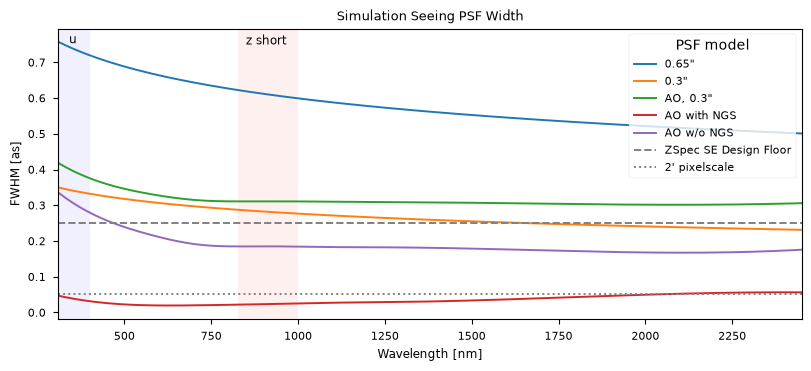

/Users/jibailey/src/zs-scopesim/notebooks/spie2026/zimager_fwhm.txt


In [5]:
platescale = (120 / 2304) * u.arcsec
header = ("2' platescale: {:.3f} mas/pixel\n"
          "ZSpec SE design floor: {:.0f} mas\n"
          "Wavelength [nm]  0.65\" [mas]  0.3\" [mas]  AO, 0.3\" [mas]  AO with NGS [mas]  AO w/o NGS [mas]")

zimager_fwhm_path = pathlib.Path(output_dir) / "zimager_fwhm.txt"

np.savetxt(zimager_fwhm_path,  np.column_stack([export_wave_nm.to_value(u.nm), *export_fwhm_mas]),
           fmt=["%7.1f", "%13.0f", "%13.0f", "%13.0f", "%15.0f", "%15.0f"],
           header=header.format(platescale.to_value(u.mas), (0.25 * u.arcsec).to_value(u.mas)), comments="# ")


fig, ax = plt.subplots(figsize=(8.0, 3.6), constrained_layout=True)
for case, fwhm in zip(export_cases, export_fwhm_mas):
    plt.plot(export_wave_nm, fwhm/1000, label=case[0])

plt.axhline(.25, linestyle='--', color='grey', label='ZSpec SE Design Floor')
plt.axhline(platescale.value, linestyle=':', color='grey', label="2' pixelscale")

ax.axvspan(310, 400, color="blue", alpha=0.06, lw=0)
ax.axvspan(826, 1000, color="red", alpha=0.06, lw=0)
ax.text(np.sqrt(310*400), 0.98, 'u', transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize="small", color=plt.rcParams["text.color"])
ax.text(np.sqrt(826*1000), 0.98, 'z short', transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize="small", color=plt.rcParams["text.color"])

ax.set_xlim(export_wave_nm.min().value, export_wave_nm.max().value)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("FWHM [as]")
ax.set_title("Simulation Seeing PSF Width")
ax.legend(title="PSF model")
display_and_save_figure(fig, "zimager_seeing_budget", save=False)
print(zimager_fwhm_path)